# buckleUP — chevron-braced frame, imperfection, corotational

A 2-D chevron-braced bay built purely from line elements. Each brace
carries an **L/1000 geometric imperfection** baked directly into the
geometry (via the new `add_imperfect_line` helper), a **corotational**
geometric transformation on the braces, and a linear lateral push at
the top-right corner that drives one brace into compression.

The compression brace amplifies its imperfection as the load climbs,
and the resulting deflection curve matches the classical
Perry–Robertson expression

$$
\delta_{\mathrm{perp}}(P) \;=\; \frac{\delta_0}{1 - P/P_{\mathrm{cr}}}
$$

so the notebook ends with a load–displacement plot overlaid on theory.

### Why lateral, not vertical

A chevron under a **vertical** apex load puts *both* braces into
compression and buckles in a symmetric mode, which means the
imperfection has to be carefully phased with the mode shape. A
**lateral** push at the top is instead **antisymmetric**: one brace
compresses, the other tenses, and only the compressed brace buckles.
The tension brace straightens its own imperfection out harmlessly.
This matches how real braced frames actually resist wind/seismic load.

### Imperfection math

At top-right, sum of horizontal forces:
`V − N_L · L/L_br + (N_{bR} − N_{bL}) = 0`. The beam-half axial
forces vanish because neither top node receives any horizontal load
other than through the beam itself, so `N_{bL} = N_{bR} = 0`. With
antisymmetry (`N_L = −N_R`) the apex equation gives

$$
F_{\text{brace}} \;=\; V \cdot \frac{L_{br}}{L},
\qquad
V_{cr} \;=\; P_{\text{cr,brace}} \cdot \frac{L}{L_{br}}
$$

so for our geometry the frame buckles at `V_cr ≈ 107 kN`.

In [1]:
from apeGmsh import apeGmsh, Results
import numpy as np
import matplotlib.pyplot as plt

# ---- Geometry [mm] ------------------------------------------------
L  = 4000.0     # bay width  (x)
H  = 3000.0     # storey height (y)
lc = 200.0      # mesh size

# ---- Steel material ----------------------------------------------
E   = 200_000.0      # MPa
nu  = 0.3

# ---- Column / beam section ---------------------------------------
# We want the frame to carry lateral load almost entirely through the
# brace (truss action), not through column/beam flexure (moment-frame
# action). So we keep A_frame large (columns/beams transmit axial
# force freely) but I_frame small: very low flexural stiffness at the
# column tops means the frame can't resist the lateral push except
# through the brace.
A_frame = 10_000.0   # mm^2
I_frame = 1.0e4      # mm^4   (deliberately weak in flexure)

# ---- Brace section — slender round bar d = 60 mm -----------------
d_br = 60.0
A_br = np.pi * (d_br / 2.0) ** 2
I_br = np.pi * d_br ** 4 / 64.0

# ---- Derived buckling numbers ------------------------------------
L_br        = np.sqrt((L / 2.0) ** 2 + H ** 2)
delta_0     = L_br / 1000.0
P_cr_brace  = np.pi ** 2 * E * I_br / L_br ** 2       # ideal pin-pin
V_cr_ideal  = P_cr_brace * L / L_br                    # if brace carries all V

print(f'L_brace    = {L_br:.1f} mm   delta_0 = L/1000 = {delta_0:.3f} mm')
print(f'A_brace    = {A_br:.1f} mm^2  I_brace = {I_br:.0f} mm^4')
print(f'P_cr per brace (pin-pin) = {P_cr_brace/1e3:.2f} kN')
print(f'V_cr_ideal (if brace takes all V) = {V_cr_ideal/1e3:.2f} kN')

L_brace    = 3605.6 mm   delta_0 = L/1000 = 3.606 mm
A_brace    = 2827.4 mm^2  I_brace = 636173 mm^4
P_cr per brace (pin-pin) = 96.60 kN
V_cr_ideal (if brace takes all V) = 107.16 kN


## 1. Build the frame geometry

All members are lines in the X–Y plane (z = 0). The columns and beams
are standard `add_line` calls; the two braces go through the new
`add_imperfect_line` helper with `shape='kink'` and an **outward**
perpendicular direction. `add_imperfect_line` handles the projection
automatically — we just pass a rough direction hint.

In [2]:
m = apeGmsh(model_name='buckleUP', verbose=False)
m.begin()

# Corner / apex points.
p_bL = m.model.geometry.add_point(0,   0, 0, lc=lc, label='base_left')
p_bR = m.model.geometry.add_point(L,   0, 0, lc=lc, label='base_right')
p_tL = m.model.geometry.add_point(0,   H, 0, lc=lc, label='top_left')
p_tR = m.model.geometry.add_point(L,   H, 0, lc=lc, label='top_right')
p_ap = m.model.geometry.add_point(L/2, H, 0, lc=lc, label='apex')

# Columns + beam halves (straight lines).
col_L = m.model.geometry.add_line(p_bL, p_tL, label='col_left')
col_R = m.model.geometry.add_line(p_bR, p_tR, label='col_right')
m.physical.add_curve(tags=[col_L, col_R], name='pg_columns')

beam_L = m.model.geometry.add_line(p_tL, p_ap, label='beam_left')
beam_R = m.model.geometry.add_line(p_ap, p_tR, label='beam_right')
m.physical.add_curve(tags=[beam_L, beam_R], name='pg_beams')

# Chevron braces — each built with a midspan kink perpendicular to its
# own axis, pointing OUTWARD (away from the frame centreline). The
# helper projects the direction vector onto the plane perpendicular to
# the line axis, so we can pass a coarse hint and still get a true
# perpendicular offset of the requested magnitude.
br_L_tags = m.model.geometry.add_imperfect_line(
    p_bL, p_ap,
    magnitude=delta_0,
    direction=(-1, 0, 0),       # outward on the left side
    shape='kink',
    label='brace_left',
)
br_R_tags = m.model.geometry.add_imperfect_line(
    p_bR, p_ap,
    magnitude=delta_0,
    direction=(+1, 0, 0),       # outward on the right side
    shape='kink',
    label='brace_right',
)
m.physical.add_curve(
    tags=[*br_L_tags, *br_R_tags],
    name='pg_braces',
)

m.mesh.sizing.set_global_size(lc)
m.mesh.generation.generate(dim=1)

m.model.preview(browser=True)
m.mesh.preview(browser=True)

# m.model.viewer()
# m.mesh.viewer()

fem = m.mesh.queries.get_fem_data(remove_orphans=True)

m.end()

print(f'total nodes: {len(fem.nodes.ids)}')
for g in fem.elements:
    print(f'  {g.type_name:6s} n={len(g)}')


total nodes: 89
  line2  n=90
  point1 n=7


In [3]:
fem.inspect.physical_table()

name  n_nodes  n_elems
dim pg_tag                              
1   8       pg_columns       32       30
    11        pg_beams       21       20
    14       pg_braces       41       40

## 2. Verify the imperfection is actually in the geometry

Iterate every brace node and compute its **perpendicular distance** to
the straight pin-to-pin line. For a clean kink imperfection we expect
the midspan node to sit exactly `δ₀ = L/1000` off-axis and every other
node to sit on the straight line between the endpoint and the kink.

In [4]:
def perp_distance_from_axis(coord, p_start, p_end):
    axis = p_end - p_start
    L = np.linalg.norm(axis)
    u  = axis / L
    r  = coord - p_start
    s  = np.dot(r, u)
    along = p_start + s * u
    return np.linalg.norm(coord - along)

# Right brace: from base-right (L, 0) to apex (L/2, H).
p_start = np.array([L,   0, 0])
p_end   = np.array([L/2, H, 0])

br_R_ids    = list(int(n) for n in fem.nodes.get_ids(target='brace_right'))
br_R_coords = fem.nodes.get_coords(target='brace_right')

print(f'brace_right has {len(br_R_ids)} nodes')
print(f'{"x":>8s} {"y":>8s}   perp offset [mm]')
order = np.argsort(-br_R_coords[:, 0])          # right -> apex order
for idx in order:
    c = br_R_coords[idx]
    d = perp_distance_from_axis(c, p_start, p_end)
    print(f'{c[0]:8.2f} {c[1]:8.2f}   {d:+7.3f}')

print(f'\nexpected midspan offset = L_br/1000 = {delta_0:.3f} mm')

brace_right has 21 nodes
       x        y   perp offset [mm]
 4000.00     0.00    +0.000
 3900.30   150.20    +0.361
 3800.60   300.40    +0.721
 3700.90   450.60    +1.082
 3601.20   600.80    +1.442
 3501.50   751.00    +1.803
 3401.80   901.20    +2.163
 3302.10  1051.40    +2.524
 3202.40  1201.60    +2.884
 3102.70  1351.80    +3.245
 3003.00  1502.00    +3.606
 2902.70  1651.80    +3.245
 2802.40  1801.60    +2.884
 2702.10  1951.40    +2.524
 2601.80  2101.20    +2.163
 2501.50  2251.00    +1.803
 2401.20  2400.80    +1.442
 2300.90  2550.60    +1.082
 2200.60  2700.40    +0.721
 2100.30  2850.20    +0.361
 2000.00  3000.00    +0.000

expected midspan offset = L_br/1000 = 3.606 mm


## 3. Build the OpenSees model

2-D frame with `ndm=2, ndf=3`. Columns and beams use a `Linear`
transformation (no geometric nonlinearity there — the frame members
are stiff and are not supposed to buckle). Braces use **`Corotational`**
so the rotation of the chord captures the second-order response
needed for Euler amplification.

In [5]:
import openseespy.opensees as ops

ops.wipe()
ops.model('basic', '-ndm', 2, '-ndf', 3)
ops.timeSeries('Linear', 1)

# --- Nodes --------------------------------------------------------
for nid, xyz in fem.nodes.get():
    ops.node(nid, xyz[0], xyz[1])

# --- Base fixities (fully fixed) ---------------------------------
for label in ('base_left', 'base_right'):
    nid = int(fem.nodes.get_ids(target=label)[0])
    ops.fix(nid, 1, 1, 1)

# --- Geometric transformations ------------------------------------
linear_tag = 1
corot_tag  = 2
ops.geomTransf('Linear',       linear_tag)
ops.geomTransf('Corotational', corot_tag)

# --- Columns & beams (linear transformation, stiff section) ------
n_frame = 0
for group in fem.elements.get(target=['pg_columns', 'pg_beams']):
    for eid, conn in group:
        ni, nj = int(conn[0]), int(conn[1])
        ops.element('elasticBeamColumn', int(eid), ni, nj,
                    A_frame, E, I_frame, linear_tag)
        n_frame += 1

# --- Braces (corotational, slender round bar, pin-pin ends) -----
# To get a true pin-ended brace that matches the idealised pin-pin
# P_cr = pi^2 EI/L^2, we release the bending moment at the brace's
# outer-most element ends — the ones actually sitting on a frame
# joint (base or apex). Interior brace elements stay moment-
# connected so the element chain can still bend into a buckled
# shape.
#
# 2-D elasticBeamColumn release codes:
#   0  — no release
#   1  — release M_z at node i
#   2  — release M_z at node j
#   3  — release M_z at both ends
joint_nids = {
    int(fem.nodes.get_ids(target='base_left')[0]),
    int(fem.nodes.get_ids(target='base_right')[0]),
    int(fem.nodes.get_ids(target='apex')[0]),
}

n_brace = 0
for group in fem.elements.get(target='pg_braces'):
    for eid, conn in group:
        ni, nj = int(conn[0]), int(conn[1])
        release = 0
        if ni in joint_nids:
            release = 1
        if nj in joint_nids:
            release = 2 if release == 0 else 3
        if release:
            ops.element('elasticBeamColumn', int(eid), ni, nj,
                        A_br, E, I_br, corot_tag,
                        '-release', release)
        else:
            ops.element('elasticBeamColumn', int(eid), ni, nj,
                        A_br, E, I_br, corot_tag)
        n_brace += 1

print(f'frame elements (linear transf)      : {n_frame}')
print(f'brace elements (corotational)       : {n_brace}')
print(f'  (brace ends moment-released at joints)')

frame elements (linear transf)      : 50
brace elements (corotational)       : 40
  (brace ends moment-released at joints)


## 4. Apply the lateral load and run a load-controlled analysis

Reference load of 1 N in +x at the top-right corner; integrator steps
advance the load factor so the current applied force = load factor.
We ramp to ~0.93·V_cr in 50 load-control steps and capture the current
load, the top-right horizontal drift, and the **perpendicular**
deflection of the kink on the compression brace (right one).

In [6]:
tR_nid = int(fem.nodes.get_ids(target='top_right')[0])

ops.pattern('Plain', 1, 1)
ops.load(tR_nid, 1.0, 0.0, 0.0)     # unit reference push

ops.constraints('Transformation')
ops.numberer('RCM')
ops.system('UmfPack')
ops.test('NormDispIncr', 1.0e-8, 200)
ops.algorithm('Newton')

# Ramp to 0.93·V_cr_ideal. With pin-pin brace ends and a weak frame
# moment-action, V·L_br/L is essentially the brace compression and
# the idealised pin-pin P_cr is the one that actually matters.
V_target = 0.93 * V_cr_ideal
n_steps  = 60
dV       = V_target / n_steps
ops.integrator('LoadControl', dV)
ops.analysis('Static')

# --- Locate the kink node on the compression (right) brace -------
p_start = np.array([L,   0, 0])
p_end   = np.array([L/2, H, 0])
axis    = p_end - p_start
L_axis  = np.linalg.norm(axis)
u_axis  = axis / L_axis

br_R_ids    = np.array(
    [int(n) for n in fem.nodes.get_ids(target='brace_right')])
br_R_coords = fem.nodes.get_coords(target='brace_right')
perp_offsets = np.array([
    np.linalg.norm(c - (p_start + np.dot(c - p_start, u_axis) * u_axis))
    for c in br_R_coords
])
kink_idx = int(np.argmax(perp_offsets))
kink_nid = int(br_R_ids[kink_idx])
print(f'kink node id = {kink_nid}  '
      f'initial perp offset = {perp_offsets[kink_idx]:.3f} mm')

# Outward perpendicular unit vector for the right brace.
perp_R = np.array([H, L/2, 0]) / L_axis

# --- Pick ONE element in the right brace for axial-force sampling.
brace_R_element_ids = []
for group in fem.elements.get(target='brace_right'):
    for eid, _conn in group:
        brace_R_element_ids.append(int(eid))
probe_eid = brace_R_element_ids[len(brace_R_element_ids) // 2]
print(f'probing F_brace via element {probe_eid} (mid of right brace)')

# --- Histories ---------------------------------------------------
hist_V      = []
hist_uTR    = []
hist_kperp  = []
hist_Fbrace = []
disp_per_step: list[np.ndarray] = []
n_nodes = len(fem.nodes.ids)

for step in range(n_steps):
    ok = ops.analyze(1)
    if ok != 0:
        print(f'analysis failed at step {step + 1}')
        break
    V_now = (step + 1) * dV
    uTR   = ops.nodeDisp(tR_nid, 1)
    kdx   = ops.nodeDisp(kink_nid, 1)
    kdy   = ops.nodeDisp(kink_nid, 2)
    kperp = delta_0 + kdx * perp_R[0] + kdy * perp_R[1]
    basic = ops.basicForce(probe_eid)
    F_brace_compression = -basic[0]

    hist_V.append(V_now)
    hist_uTR.append(uTR)
    hist_kperp.append(kperp)
    hist_Fbrace.append(F_brace_compression)

    # Capture full displacement field for the time-series viewer.
    d_step = np.zeros((n_nodes, 3), dtype=np.float64)
    for i, nid in enumerate(fem.nodes.ids):
        di = ops.nodeDisp(int(nid))
        d_step[i, 0] = di[0]
        d_step[i, 1] = di[1]
    disp_per_step.append(d_step)

print(f'converged in {len(hist_V)} of {n_steps} steps')
print(f'final V            = {hist_V[-1]/1e3:.2f} kN   '
      f'({hist_V[-1]/V_cr_ideal*100:.1f}% V_cr_ideal)')
print(f'final F_brace      = {hist_Fbrace[-1]/1e3:.2f} kN   '
      f'({hist_Fbrace[-1]/P_cr_brace*100:.1f}% P_cr_brace)')
print(f'final top-R drift  = {hist_uTR[-1]:.3f} mm')
print(f'final kink perp    = {hist_kperp[-1]:.3f} mm   '
      f'(amplification = {hist_kperp[-1]/delta_0:.2f}x)')

kink node id = 7  initial perp offset = 3.606 mm
probing F_brace via element 86 (mid of right brace)


converged in 60 of 60 steps
final V            = 99.66 kN   (93.0% V_cr_ideal)
final F_brace      = 89.79 kN   (93.0% P_cr_brace)
final top-R drift  = 2.130 mm
final kink perp    = 41.676 mm   (amplification = 11.56x)


## 5. Compare to Perry–Robertson

The classical mid-span deflection of a pin-ended column with an
initial imperfection `δ₀` under an axial compression `P` is

$$
\delta(P) \;=\; \frac{\delta_0}{1 - P/P_{\mathrm{cr}}}
$$

so long as the material stays linear-elastic. For our frame
`F_brace = V · L_br/L`, so we plot the FEM curve `(V, δ_perp)` against
`(V, δ₀ / (1 − V·L_br/(L·P_cr_brace)))`.

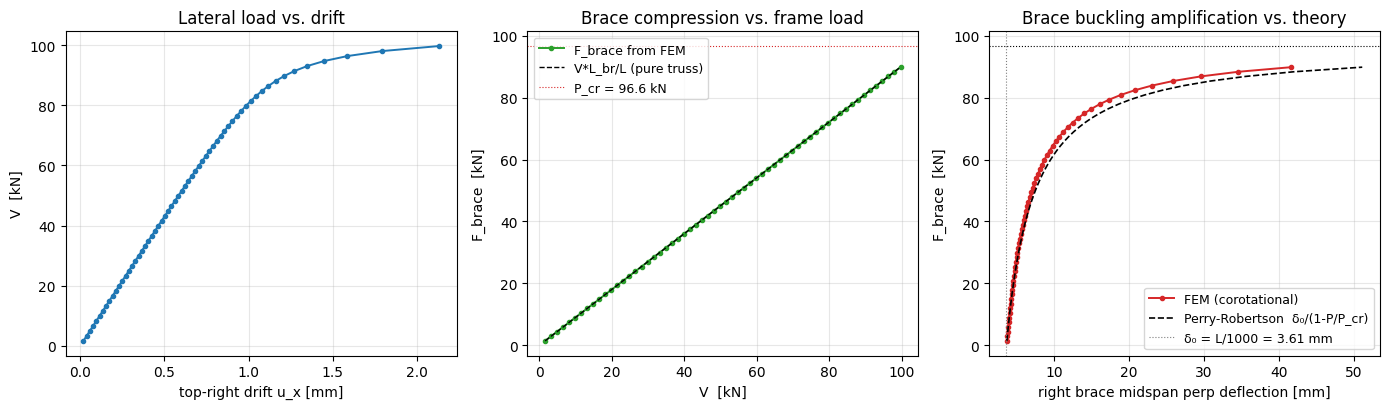

In [7]:
hist_V      = np.asarray(hist_V)
hist_uTR    = np.asarray(hist_uTR)
hist_kperp  = np.asarray(hist_kperp)
hist_Fbrace = np.asarray(hist_Fbrace)

# Perry–Robertson curve — parameterised by ACTUAL brace compression
# force from the FEM, not the idealised V·L_br/L. This is what matches
# theory directly: δ = δ₀ / (1 − F_brace/P_cr).
eta         = hist_Fbrace / P_cr_brace
valid       = eta < 0.995
delta_theory = delta_0 / (1.0 - eta[valid])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# (a) V vs top-right drift
ax = axes[0]
ax.plot(hist_uTR, hist_V / 1e3, 'o-', lw=1.4, ms=3, color='tab:blue')
ax.set_xlabel('top-right drift u_x [mm]')
ax.set_ylabel('V  [kN]')
ax.set_title('Lateral load vs. drift')
ax.grid(True, alpha=0.3)

# (b) V vs F_brace — truss-action fraction (linear at first, bends at P_cr)
ax = axes[1]
ax.plot(hist_V / 1e3, hist_Fbrace / 1e3, 'o-', lw=1.4, ms=3,
        color='tab:green', label='F_brace from FEM')
# Idealised V*L_br/L line (truss-only action)
ax.plot(hist_V / 1e3, hist_V * L_br / L / 1e3, 'k--', lw=1.0,
        label='V*L_br/L (pure truss)')
ax.axhline(P_cr_brace / 1e3, color='tab:red', lw=0.8, ls=':',
           label=f'P_cr = {P_cr_brace/1e3:.1f} kN')
ax.set_xlabel('V  [kN]')
ax.set_ylabel('F_brace  [kN]')
ax.set_title('Brace compression vs. frame load')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left', fontsize=9)

# (c) F_brace vs compression-brace kink perp deflection + Perry theory
ax = axes[2]
ax.plot(hist_kperp, hist_Fbrace / 1e3, 'o-', lw=1.4, ms=3,
        color='tab:red', label='FEM (corotational)')
ax.plot(delta_theory, hist_Fbrace[valid] / 1e3, 'k--', lw=1.2,
        label='Perry-Robertson  \u03b4\u2080/(1-P/P_cr)')
ax.axhline(P_cr_brace / 1e3, color='k', lw=0.8, ls=':')
ax.axvline(delta_0, color='tab:gray', lw=0.8, ls=':',
           label=f'\u03b4\u2080 = L/1000 = {delta_0:.2f} mm')
ax.set_xlabel('right brace midspan perp deflection [mm]')
ax.set_ylabel('F_brace  [kN]')
ax.set_title('Brace buckling amplification vs. theory')
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Deformed view with pseudo-time history

Every analysis step is pushed to `Results.from_fem` as a **time step**
— `time = V` (the lateral load in N) — so the apeGmsh viewer can scrub
through the loading sequence and animate the compression brace
progressively bowing out. Each step carries its own displacement
field, magnitude, and a scalar `F_brace` for contour colouring.

The frame is 1-D lines, so we pass `include_pgs` for all three groups
(`pg_columns`, `pg_beams`, `pg_braces`) to force every segment into
the viewer mesh — without this flag `Results.from_fem` would skip the
lower-dim PGs under its z-fighting guard.

## 9. Capture results — manual + DomainCapture paths

Two ways to produce a native-HDF5 results file consumable by the
apeGmsh ``ResultsViewer``:

1. **Manual path** — query the live OpenSees domain post-analysis,
   open a ``NativeWriter``, and write nodal displacements yourself.
   Good for one-shot snapshots and post-hoc diagnostics.
2. **DomainCapture path** — declare what to capture with
   ``Recorders().nodes(...)``, hand the spec to a ``DomainCapture``
   context, and call ``cap.step(t=...)`` after each ``ops.analyze``
   (the helper does it for you). Scales to multi-stage, transient,
   modal, and multi-recorder runs.

Both produce a file that ``Results.from_native(path).viewer()`` can
open. The viewer launch is gated on ``APEGMSH_SKIP_VIEWER`` so this
notebook is safe to run under nbconvert / CI.


In [10]:
from apeGmsh import workdir
OUT = workdir()
# DomainCapture path: declarative recorders, capture during analyze.
from apeGmsh.solvers.Recorders import Recorders
from apeGmsh.results.capture._domain import DomainCapture

recs = Recorders()
recs.nodes(components="displacement")
recs.nodes(components="reaction_force")
spec = recs.resolve(fem, ndm=2, ndf=3)

results_capture = OUT / "capture.h5"
if results_capture.exists():
    results_capture.unlink()

with DomainCapture(spec, results_capture, fem, ndm=2, ndf=3) as cap:
    cap.begin_stage("run", kind="static")
    # --- copied from cell 8 ---
    import openseespy.opensees as ops

    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.timeSeries('Linear', 1)

    # --- Nodes --------------------------------------------------------
    for nid, xyz in fem.nodes.get():
        ops.node(nid, xyz[0], xyz[1])

    # --- Base fixities (fully fixed) ---------------------------------
    for label in ('base_left', 'base_right'):
        nid = int(fem.nodes.get_ids(target=label)[0])
        ops.fix(nid, 1, 1, 1)

    # --- Geometric transformations ------------------------------------
    linear_tag = 1
    corot_tag  = 2
    ops.geomTransf('Linear',       linear_tag)
    ops.geomTransf('Corotational', corot_tag)

    # --- Columns & beams (linear transformation, stiff section) ------
    n_frame = 0
    for group in fem.elements.get(target=['pg_columns', 'pg_beams']):
        for eid, conn in group:
            ni, nj = int(conn[0]), int(conn[1])
            ops.element('elasticBeamColumn', int(eid), ni, nj,
                        A_frame, E, I_frame, linear_tag)
            n_frame += 1

    # --- Braces (corotational, slender round bar, pin-pin ends) -----
    # To get a true pin-ended brace that matches the idealised pin-pin
    # P_cr = pi^2 EI/L^2, we release the bending moment at the brace's
    # outer-most element ends — the ones actually sitting on a frame
    # joint (base or apex). Interior brace elements stay moment-
    # connected so the element chain can still bend into a buckled
    # shape.
    #
    # 2-D elasticBeamColumn release codes:
    #   0  — no release
    #   1  — release M_z at node i
    #   2  — release M_z at node j
    #   3  — release M_z at both ends
    joint_nids = {
        int(fem.nodes.get_ids(target='base_left')[0]),
        int(fem.nodes.get_ids(target='base_right')[0]),
        int(fem.nodes.get_ids(target='apex')[0]),
    }

    n_brace = 0
    for group in fem.elements.get(target='pg_braces'):
        for eid, conn in group:
            ni, nj = int(conn[0]), int(conn[1])
            release = 0
            if ni in joint_nids:
                release = 1
            if nj in joint_nids:
                release = 2 if release == 0 else 3
            if release:
                ops.element('elasticBeamColumn', int(eid), ni, nj,
                            A_br, E, I_br, corot_tag,
                            '-release', release)
            else:
                ops.element('elasticBeamColumn', int(eid), ni, nj,
                            A_br, E, I_br, corot_tag)
            n_brace += 1

    print(f'frame elements (linear transf)      : {n_frame}')
    print(f'brace elements (corotational)       : {n_brace}')
    print(f'  (brace ends moment-released at joints)')
    # --- copied from cell 10 ---
    tR_nid = int(fem.nodes.get_ids(target='top_right')[0])

    ops.pattern('Plain', 1, 1)
    ops.load(tR_nid, 1.0, 0.0, 0.0)     # unit reference push

    ops.constraints('Transformation')
    ops.numberer('RCM')
    ops.system('UmfPack')
    ops.test('NormDispIncr', 1.0e-8, 200)
    ops.algorithm('Newton')

    # Ramp to 0.93·V_cr_ideal. With pin-pin brace ends and a weak frame
    # moment-action, V·L_br/L is essentially the brace compression and
    # the idealised pin-pin P_cr is the one that actually matters.
    V_target = 0.93 * V_cr_ideal
    n_steps  = 60
    dV       = V_target / n_steps
    ops.integrator('LoadControl', dV)
    ops.analysis('Static')

    # --- Locate the kink node on the compression (right) brace -------
    p_start = np.array([L,   0, 0])
    p_end   = np.array([L/2, H, 0])
    axis    = p_end - p_start
    L_axis  = np.linalg.norm(axis)
    u_axis  = axis / L_axis

    br_R_ids    = np.array(
        [int(n) for n in fem.nodes.get_ids(target='brace_right')])
    br_R_coords = fem.nodes.get_coords(target='brace_right')
    perp_offsets = np.array([
        np.linalg.norm(c - (p_start + np.dot(c - p_start, u_axis) * u_axis))
        for c in br_R_coords
    ])
    kink_idx = int(np.argmax(perp_offsets))
    kink_nid = int(br_R_ids[kink_idx])
    print(f'kink node id = {kink_nid}  '
          f'initial perp offset = {perp_offsets[kink_idx]:.3f} mm')

    # Outward perpendicular unit vector for the right brace.
    perp_R = np.array([H, L/2, 0]) / L_axis

    # --- Pick ONE element in the right brace for axial-force sampling.
    brace_R_element_ids = []
    for group in fem.elements.get(target='brace_right'):
        for eid, _conn in group:
            brace_R_element_ids.append(int(eid))
    probe_eid = brace_R_element_ids[len(brace_R_element_ids) // 2]
    print(f'probing F_brace via element {probe_eid} (mid of right brace)')

    # --- Histories ---------------------------------------------------
    hist_V      = []
    hist_uTR    = []
    hist_kperp  = []
    hist_Fbrace = []
    disp_per_step: list[np.ndarray] = []
    n_nodes = len(fem.nodes.ids)

    for step in range(n_steps):
        ok = ops.analyze(1)
        cap.step(t=ops.getTime())
        if ok != 0:
            print(f'analysis failed at step {step + 1}')
            break
        V_now = (step + 1) * dV
        uTR   = ops.nodeDisp(tR_nid, 1)
        kdx   = ops.nodeDisp(kink_nid, 1)
        kdy   = ops.nodeDisp(kink_nid, 2)
        kperp = delta_0 + kdx * perp_R[0] + kdy * perp_R[1]
        basic = ops.basicForce(probe_eid)
        F_brace_compression = -basic[0]

        hist_V.append(V_now)
        hist_uTR.append(uTR)
        hist_kperp.append(kperp)
        hist_Fbrace.append(F_brace_compression)

        # Capture full displacement field for the time-series viewer.
        d_step = np.zeros((n_nodes, 3), dtype=np.float64)
        for i, nid in enumerate(fem.nodes.ids):
            di = ops.nodeDisp(int(nid))
            d_step[i, 0] = di[0]
            d_step[i, 1] = di[1]
        disp_per_step.append(d_step)

    print(f'converged in {len(hist_V)} of {n_steps} steps')
    print(f'final V            = {hist_V[-1]/1e3:.2f} kN   '
          f'({hist_V[-1]/V_cr_ideal*100:.1f}% V_cr_ideal)')
    print(f'final F_brace      = {hist_Fbrace[-1]/1e3:.2f} kN   '
          f'({hist_Fbrace[-1]/P_cr_brace*100:.1f}% P_cr_brace)')
    print(f'final top-R drift  = {hist_uTR[-1]:.3f} mm')
    print(f'final kink perp    = {hist_kperp[-1]:.3f} mm   '
          f'(amplification = {hist_kperp[-1]/delta_0:.2f}x)')
    cap.end_stage()

print(f"capture -> {results_capture} ({results_capture.stat().st_size/1024:.1f} KB)")


frame elements (linear transf)      : 50
brace elements (corotational)       : 40
  (brace ends moment-released at joints)
kink node id = 7  initial perp offset = 3.606 mm
probing F_brace via element 86 (mid of right brace)


converged in 60 of 60 steps
final V            = 99.66 kN   (93.0% V_cr_ideal)
final F_brace      = 89.79 kN   (93.0% P_cr_brace)
final top-R drift  = 2.130 mm
final kink perp    = 41.676 mm   (amplification = 11.56x)


capture -> example_buckleUP_capture.h5 (266.7 KB)


In [11]:
# Open the captured run in the apeGmsh ResultsViewer (subprocess, non-blocking).
# Set APEGMSH_SKIP_VIEWER=1 in the environment to skip the GUI under nbconvert / CI.
from apeGmsh.results import Results
results = Results.from_native(results_capture)
results.viewer(blocking=False)


[skip viewer] APEGMSH_SKIP_VIEWER set
